# Inferring dataset

In [1]:
import pandas as pd
import ast
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.colors as mcolors

In [2]:
def safe_literal_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

def select_CA(ca_positions, n_authors):
    if not ca_positions:  # no CA, just in case
        return None, None
    if 0 in ca_positions:
        return 0, 'First'
    elif (n_authors - 1) in ca_positions:
        return n_authors - 1, 'Last'
    else:
        return ca_positions[0], 'Middle'

threshold_mid = 0.2
threshold = 0.3

df = pd.read_csv('../data/interim/initial_dataset_trial.csv').drop(columns = ['Unnamed: 0'])
df['corresponding'] = df['corresponding'].apply(safe_literal_eval)
df['countries'] = df['countries'].apply(safe_literal_eval)
df['french_position'] = df['countries'].apply(lambda lst: [i for i, inner in enumerate(lst) if 'FR' in inner])

no_corr_mask = df['corresponding'].apply(lambda x: all(v is False for v in x))
df_tmp = df[~no_corr_mask]


df_tmp['CA_positions'] = df_tmp['corresponding'].apply(lambda lst: [i for i, v in enumerate(lst) if v])
df_tmp['len'] = df_tmp['corresponding'].apply(lambda x: len(x))
df_tmp = df_tmp[df_tmp.apply(lambda row: bool(set(row['CA_positions']) & set(row['french_position'])), axis = 1)]

df_tmp[['keep_CA_position', 'position']] = df_tmp.apply(lambda x: pd.Series(select_CA(x['CA_positions'], x['len'])), axis = 1)
priority_map = {'First': 3, 'Last': 2, 'Middle': 1}
df_tmp['priority'] = df_tmp['position'].map(priority_map)

grouped_journal = df_tmp.groupby(['journal', 'position']).size().unstack().fillna(0)
grouped_journal['Total'] = grouped_journal.sum(axis=1)
grouped_journal['First_pct'] = grouped_journal['First'] / grouped_journal['Total']
grouped_journal['Last_pct'] = grouped_journal['Last'] / grouped_journal['Total']
grouped_journal['Middle_pct'] = grouped_journal['Middle'] / grouped_journal['Total']
grouped_journal['entropy'] = grouped_journal.apply(lambda x: -sum((x[pct] * np.log2(x[pct]) for pct in ['First_pct', 'Last_pct', 'Middle_pct'] if x[pct] > 0)) / np.log2(3),axis=1)

df_not_CA = df[~df.doi.isin(df_tmp.doi)].reset_index(drop = True).drop(columns = ['french_position'])
df_not_CA['First_Last_FR'] = df_not_CA.countries.apply(lambda x: bool(x) and ('FR' in x[0] or 'FR' in x[-1]))
df_not_CA_rem_not_FR = df_not_CA[df_not_CA.First_Last_FR == True].reset_index(drop = True) # TO DISCARD THE ONES WITH NO FRENCH IN FIRST OR LAST
del df

discard_mid = grouped_journal[grouped_journal['Middle_pct'] > threshold_mid] # DISCARD MIDDLE HIGHER THAN THRESHOLD
df_not_CA_rem_not_FR_tmp = df_not_CA_rem_not_FR[~df_not_CA_rem_not_FR.journal.isin(discard_mid.index)].reset_index(drop = True)

discard_ent = grouped_journal[grouped_journal['entropy'] > threshold]
df_inferred_tmp = df_not_CA_rem_not_FR_tmp[~df_not_CA_rem_not_FR_tmp.journal.isin(discard_ent.index)].reset_index(drop = True)  # THE ONES FROM WHICH WE SHOULD THINK ANOTHER OPTION
df_survive = df_not_CA_rem_not_FR_tmp[df_not_CA_rem_not_FR_tmp.journal.isin(discard_ent.index)].reset_index(drop = True)  # THE ONES FROM WHICH WE SHOULD THINK ANOTHER OPTION

df_survive_not_fr = df_survive[df_survive.language != 'fr'].reset_index(drop = True)
df_survive_fr = df_survive[df_survive.language == 'fr'].reset_index(drop = True)
df_survive_not_fr['Number_of_FR'] = df_survive_not_fr['countries'].apply(lambda x: sum(sublist.count('FR') for sublist in x))
df_survive_not_fr['Number_authors'] = df_survive_not_fr['countries'].apply(lambda x: len(x))
df_survive_not_fr['Ratio'] = df_survive_not_fr['Number_of_FR'] / df_survive_not_fr['Number_authors']
df_survive_not_fr_most_fr = df_survive_not_fr[df_survive_not_fr['Ratio'] > 0.5].reset_index(drop = True)

df_inferred_tmp = pd.concat([df_inferred_tmp, df_survive_fr, df_survive_not_fr_most_fr.drop(columns = ['Number_of_FR', 'Number_authors', 'Ratio'])], ignore_index = True) \
                  .drop_duplicates('doi').reset_index(drop = True)

df_inferred = df_inferred_tmp.merge(grouped_journal[['First_pct', 'Last_pct', 'Middle_pct']], on = 'journal')

df_inclusive = pd.concat((df_tmp.drop(columns = ['french_position', 'CA_positions', 'len', 'position']), df_inferred), ignore_index = True).drop_duplicates('doi').reset_index(drop = True)
df_inclusive

/tmp/ipykernel_4103/2874509444.py:22: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/interim/initial_dataset_trial.csv').drop(columns = ['Unnamed: 0'])
/tmp/ipykernel_4103/2874509444.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['CA_positions'] = df_tmp['corresponding'].apply(lambda lst: [i for i, v in enumerate(lst) if v])
/tmp/ipykernel_4103/2874509444.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp[

,doi,publication_year,language,field_name_top_topic,journal,journal_id,issn_l,publisher,publisher_id,display_name_institution,...,corresponding,countries,doi_corr,BSO,keep_CA_position,priority,First_Last_FR,First_pct,Last_pct,Middle_pct
0,https://doi.org/10.1016/j.ejca.2012.12.027,2013,en,Medicine,European Journal of Cancer,S16731738,0959-8049,Elsevier BV,P4310320990,['Centre international de recherche sur le can...,...,"[True, False, False, False, False, False, Fals...","[[FR], [FR], [FR], [IT], [NL], [IE], [FR], [FR]]",10.1016/j.ejca.2012.12.027,True,0.0,3.0,NaN,NaN,NaN,NaN
1,https://doi.org/10.1016/j.immuni.2013.10.003,2013,en,Medicine,Immunity,S199671312,1074-7613,Cell Press,P4310315673,"['Centre de Recherche des Cordeliers', 'Déléga...",...,"[False, False, False, False, False, False, Fal...","[[FR], [FR], [FR], [FR], [DE, FR], [AT], [FR],...",10.1016/j.immuni.2013.10.003,True,16.0,2.0,NaN,NaN,NaN,NaN
2,https://doi.org/10.1016/j.jacc.2013.10.029,2013,en,Medicine,Journal of the American College of Cardiology,S60865174,0735-1097,Elsevier BV,P4310320990,"[""Laboratoire d'Excellence en Recherche sur le...",...,"[True, False, False, False, False, False, Fals...","[[FR], [GB], [CA], [AU], [GB], [DE], [ES], [IN...",10.1016/j.jacc.2013.10.029,True,0.0,3.0,NaN,NaN,NaN,NaN
3,https://doi.org/10.1093/eurheartj/eht273,2013,en,Medicine,European Heart Journal,S181568219,0195-668X,Oxford University Press,P4310311648,"['Copenhagen University Hospital', 'Herlev Hos...",...,"[True, True, False, False, False, False, False...","[[DK], [FR], [GB], [US], [ES], [BE], [SE], [CA...",10.1093/eurheartj/eht273,True,0.0,3.0,NaN,NaN,NaN,NaN
4,https://doi.org/10.1016/j.jbusvent.2013.07.003,2013,en,"Business, Management and Accounting",Journal of Business Venturing,S66201313,0883-9026,Elsevier BV,P4310320990,"['UCLouvain', 'UCLouvain', 'Université Lille N...",...,"[False, False, True]","[[BE], [BE, FR], [FR]]",10.1016/j.jbusvent.2013.07.003,True,2.0,2.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1008306,https://doi.org/10.5802/crgeos.70,2021,en,Earth and Planetary Sciences,Comptes Rendus Géoscience,S113329220,NaN,Elsevier BV,P4310320990,"['Université Savoie Mont Blanc', 'Institut de ...",...,"[True, False, False, False, False, False, Fals...","[[], [FR], [FR], [FR], [FR], [FR], [FR], [FR]]",10.5802/crgeos.70,True,NaN,NaN,True,0.908451,0.014085,0.077465
1008307,https://doi.org/10.1080/00927872.2022.2096224,2022,en,Arts and Humanities,Communications in Algebra,S53865935,NaN,Taylor & Francis,P4310320547,"['Laboratoire de Mathématiques', 'Université d...",...,"[False, True, False]","[[FR], [PT], [FR, TN]]",10.1080/00927872.2022.2096224,True,NaN,NaN,True,0.830986,0.126761,0.042254
1008308,https://doi.org/10.1016/j.jebo.2023.12.013,2023,en,"Economics, Econometrics and Finance",Journal of Economic Behavior & Organization,S62201805,NaN,Elsevier BV,P4310320990,"['University of Brescia', 'Fondazione Eni Enri...",...,"[True, False, False, False]","[[IT], [FR], [FR], [FR, IT]]",10.1016/j.jebo.2023.12.013,True,NaN,NaN,True,0.505155,0.329897,0.164948
1008309,https://doi.org/10.1093/ej/uead059,2023,en,Social Sciences,The Economic Journal,S45992627,NaN,Oxford University Press,P4310311648,['Institut für Arbeitsmarkt und Berufsforschun...,...,"[True, False, False]","[[DE], [FR], [FR]]",10.1093/ej/uead059,True,NaN,NaN,True,0.625000,0.250000,0.125000


In [3]:
### MISSING
#### THERE CAN BE JOURNALS THAT ARE NOT IN THE CA SUBSET SO ITS NOT POSSIBLE TO INFER THEM BUT HAVE APC_PAID NOT NA. WE CAN'T INCLUDE THOSE
#### THERE ARE 62335 PAPERS THAT WE CAN'T INFER BECAUSE OF THE TRHESHOLS, LANGUAGE AND AUTHOR PERCENTAGE;BUT HAVE  APC_PAID NOT NA

df_tmp_1 = df_inferred_tmp[(~df_inferred_tmp.journal.isin(grouped_journal.index)) & (df_inferred_tmp.apc_paid.notna())]
df_tmp_2 = df_survive_not_fr[(df_survive_not_fr['Ratio'] <= 0.5) & (df_survive_not_fr.apc_paid.notna())].drop(columns = ['Number_of_FR', 'Number_authors', 'Ratio'])
df_tmp_2 = df_tmp_2.merge(grouped_journal[['First_pct', 'Last_pct', 'Middle_pct']], on = 'journal')

df_inclusive = pd.concat((df_inclusive, df_tmp_2), ignore_index = True).drop_duplicates('doi').reset_index(drop = True)
df_inclusive

,doi,publication_year,language,field_name_top_topic,journal,journal_id,issn_l,publisher,publisher_id,display_name_institution,...,corresponding,countries,doi_corr,BSO,keep_CA_position,priority,First_Last_FR,First_pct,Last_pct,Middle_pct
0,https://doi.org/10.1016/j.ejca.2012.12.027,2013,en,Medicine,European Journal of Cancer,S16731738,0959-8049,Elsevier BV,P4310320990,['Centre international de recherche sur le can...,...,"[True, False, False, False, False, False, Fals...","[[FR], [FR], [FR], [IT], [NL], [IE], [FR], [FR]]",10.1016/j.ejca.2012.12.027,True,0.0,3.0,NaN,NaN,NaN,NaN
1,https://doi.org/10.1016/j.immuni.2013.10.003,2013,en,Medicine,Immunity,S199671312,1074-7613,Cell Press,P4310315673,"['Centre de Recherche des Cordeliers', 'Déléga...",...,"[False, False, False, False, False, False, Fal...","[[FR], [FR], [FR], [FR], [DE, FR], [AT], [FR],...",10.1016/j.immuni.2013.10.003,True,16.0,2.0,NaN,NaN,NaN,NaN
2,https://doi.org/10.1016/j.jacc.2013.10.029,2013,en,Medicine,Journal of the American College of Cardiology,S60865174,0735-1097,Elsevier BV,P4310320990,"[""Laboratoire d'Excellence en Recherche sur le...",...,"[True, False, False, False, False, False, Fals...","[[FR], [GB], [CA], [AU], [GB], [DE], [ES], [IN...",10.1016/j.jacc.2013.10.029,True,0.0,3.0,NaN,NaN,NaN,NaN
3,https://doi.org/10.1093/eurheartj/eht273,2013,en,Medicine,European Heart Journal,S181568219,0195-668X,Oxford University Press,P4310311648,"['Copenhagen University Hospital', 'Herlev Hos...",...,"[True, True, False, False, False, False, False...","[[DK], [FR], [GB], [US], [ES], [BE], [SE], [CA...",10.1093/eurheartj/eht273,True,0.0,3.0,NaN,NaN,NaN,NaN
4,https://doi.org/10.1016/j.jbusvent.2013.07.003,2013,en,"Business, Management and Accounting",Journal of Business Venturing,S66201313,0883-9026,Elsevier BV,P4310320990,"['UCLouvain', 'UCLouvain', 'Université Lille N...",...,"[False, False, True]","[[BE], [BE, FR], [FR]]",10.1016/j.jbusvent.2013.07.003,True,2.0,2.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1031870,https://doi.org/10.1007/s10618-023-00941-9,2023,en,Arts and Humanities,Data Mining and Knowledge Discovery,S121920818,NaN,Springer Science+Business Media,P4310319900,['FORTH Institute of Electronic Structure and ...,...,"[True, False, False, False]","[[GR], [GR], [FR], [FR]]",10.1007/s10618-023-00941-9,True,NaN,NaN,True,0.846154,0.076923,0.076923
1031871,https://doi.org/10.3390/su151410786,2023,en,"Business, Management and Accounting",Sustainability,S10134376,NaN,Multidisciplinary Digital Publishing Institute,P4310310987,"['NEOMA Business School', 'UCLouvain', 'L’Inst...",...,"[False, True, False, False]","[[FR], [BE], [BE], [BE]]",10.3390/su151410786,True,NaN,NaN,True,0.678771,0.153631,0.167598
1031872,https://doi.org/10.1140/epjs/s11734-023-00845-1,2023,lv,Physics and Astronomy,The European Physical Journal Special Topics,S138062970,NaN,Springer Science+Business Media,P4310319900,['Scuola Internazionale Superiore di Studi Ava...,...,"[True, False]","[[IT], [FR]]",10.1140/epjs/s11734-023-00845-1,True,NaN,NaN,True,0.777778,0.111111,0.111111
1031873,https://doi.org/10.1051/meca/2024015,2024,en,Engineering,Mechanics & Industry,S2479780166,NaN,EDP Sciences,P4310319748,"['""Dunarea de Jos"" University of Galati', '""Du...",...,"[True, False, False, False, False, False]","[[RO], [RO], [RO], [RO], [RO], [FR]]",10.1051/meca/2024015,True,NaN,NaN,True,0.833333,0.055556,0.111111


## National Agreements

In [2]:
df_na = pd.read_csv('../data/external/all_couperin.csv')
len(df_na[df_na.DOI.str.lower().isin(list(df_inclusive.doi.apply(lambda x: x[16::].lower())))]) / len(df_na)

/tmp/ipykernel_7548/2267344548.py:1: DtypeWarning: Columns (10,11,13,16,18,19,20,21,22,23,24,25,30,38,40,41,44,45,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df_na = pd.read_csv('../data/external/all_couperin.csv')


NameError: name 'df_inclusive' is not defined

In [3]:
df = pd.read_csv('../data/interim/initial_dataset_trial.csv').drop(columns = ['Unnamed: 0'])
df_na[df_na.DOI.str.lower().isin(list(df.doi.apply(lambda x: x[16::].lower())))]

/tmp/ipykernel_7548/1411991982.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/interim/initial_dataset_trial.csv').drop(columns = ['Unnamed: 0'])


,DOI,Publisher,Source_Files_All,Source_Type,Duplicate_Count,Year,Title,Type,Journal,Journal_Type,...,Accounting_Rule_Applied,Year_Discrepancy_Flag,Year_Other_Values,APC_Manual_Computed_Mismatch,APC_Conflict_Flag,APC_Value_Selected,APC_Value_Source,APC_Other_Values,Conflict_Note,Tracked_Couperin
0,10.1016/j.rhum.2021.09.013,Elsevier,DOI_Elsevier_2019_2022_publisher.xlsx; DOI_Els...,dashboard,2,2021.0,Recommandations de la Société française de rhu...,Full length article,Revue du rhumatisme,Hybrid,...,Elsevier I: APC after discount,True,2020 (DOI_Elsevier_2019_2022_publisher.xlsx),NaN,True,1000.0,DOI_Elsevier_2022_2025_dashboard.xlsx,1778.00|DOI_Elsevier_2019_2022_publisher.xlsx,Kept 1000.00 EUR from DOI_Elsevier_2022_2025_d...,True
1,10.1016/j.scispo.2021.08.005,Elsevier,DOI_Elsevier_2019_2022_publisher.xlsx; DOI_Els...,dashboard,2,2021.0,Impacts au Rugby à XV : suivi longitudinal et ...,Full length article,Science et Sports,Hybrid,...,Elsevier I: APC after discount,True,2022 (DOI_Elsevier_2019_2022_publisher.xlsx),NaN,True,1000.0,DOI_Elsevier_2022_2025_dashboard.xlsx,2308.00|DOI_Elsevier_2019_2022_publisher.xlsx,Kept 1000.00 EUR from DOI_Elsevier_2022_2025_d...,True
2,10.1016/j.jval.2022.05.007,Elsevier,DOI_Elsevier_2019_2022_publisher.xlsx; DOI_Els...,dashboard,2,2022.0,Where are populations aging better? A global c...,Full length article,Value in Health,Hybrid,...,Elsevier I: APC after discount,False,NaN,NaN,True,1867.0,DOI_Elsevier_2022_2025_dashboard.xlsx,0.00|DOI_Elsevier_2019_2022_publisher.xlsx,Kept 1867.00 EUR from DOI_Elsevier_2022_2025_d...,True
3,10.1016/j.neurol.2022.06.012,Elsevier,DOI_Elsevier_2019_2022_publisher.xlsx; DOI_Els...,dashboard,2,2022.0,High-clearance anti-amyloid immunotherapies in...,Review article,Revue Neurologique,Hybrid,...,Elsevier I: APC after discount,True,2021 (DOI_Elsevier_2019_2022_publisher.xlsx),NaN,True,2041.0,DOI_Elsevier_2022_2025_dashboard.xlsx,2213.00|DOI_Elsevier_2019_2022_publisher.xlsx,Kept 2041.00 EUR from DOI_Elsevier_2022_2025_d...,True
4,10.1016/j.neurol.2022.08.002,Elsevier,DOI_Elsevier_2019_2022_publisher.xlsx; DOI_Els...,dashboard,2,2022.0,High-clearance anti-amyloid immunotherapies in...,Review article,Revue Neurologique,Hybrid,...,Elsevier I: APC after discount,True,2021 (DOI_Elsevier_2019_2022_publisher.xlsx),NaN,True,2041.0,DOI_Elsevier_2022_2025_dashboard.xlsx,2100.00|DOI_Elsevier_2019_2022_publisher.xlsx,Kept 2041.00 EUR from DOI_Elsevier_2022_2025_d...,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136372,10.15252/embj.2021108306,Wiley,DOI_Wiley_2022_2024_dashboard.xlsx,dashboard,1,NaN,Multidisciplinary smile rehabilitation for an ...,NaN,Case Reports in Dentistry,Open Access,...,NaN,False,NaN,NaN,False,NaN,NaN,NaN,NaN,True
136373,10.15252/embj.2021109012,Wiley,DOI_Wiley_2022_2024_dashboard.xlsx,dashboard,1,NaN,Factors affecting wound healing after wide sur...,NaN,International Wound Journal,Open Access,...,NaN,False,NaN,NaN,False,NaN,NaN,NaN,NaN,True
136374,10.15252/embj.2022112101,Wiley,DOI_Wiley_2022_2024_dashboard.xlsx,dashboard,1,NaN,Carbogels for sustainable and scalable thermoe...,NaN,Carbon Energy,Open Access,...,NaN,False,NaN,NaN,False,NaN,NaN,NaN,NaN,True
136375,10.15252/embj.2023113590,Wiley,DOI_Wiley_2022_2024_dashboard.xlsx,dashboard,1,NaN,Outcomes of elderly patients admitted to the I...,NaN,HemaSphere,Open Access,...,NaN,False,NaN,NaN,False,NaN,NaN,NaN,NaN,True


In [9]:
df['doi_corr'] = df.doi.apply(lambda x: x[16::].lower())
df[df.doi_corr.str.lower().isin(list(df_na.DOI.str.lower()))].apc_paid.notna().sum()

np.int64(26375)

## Stack plot publisher

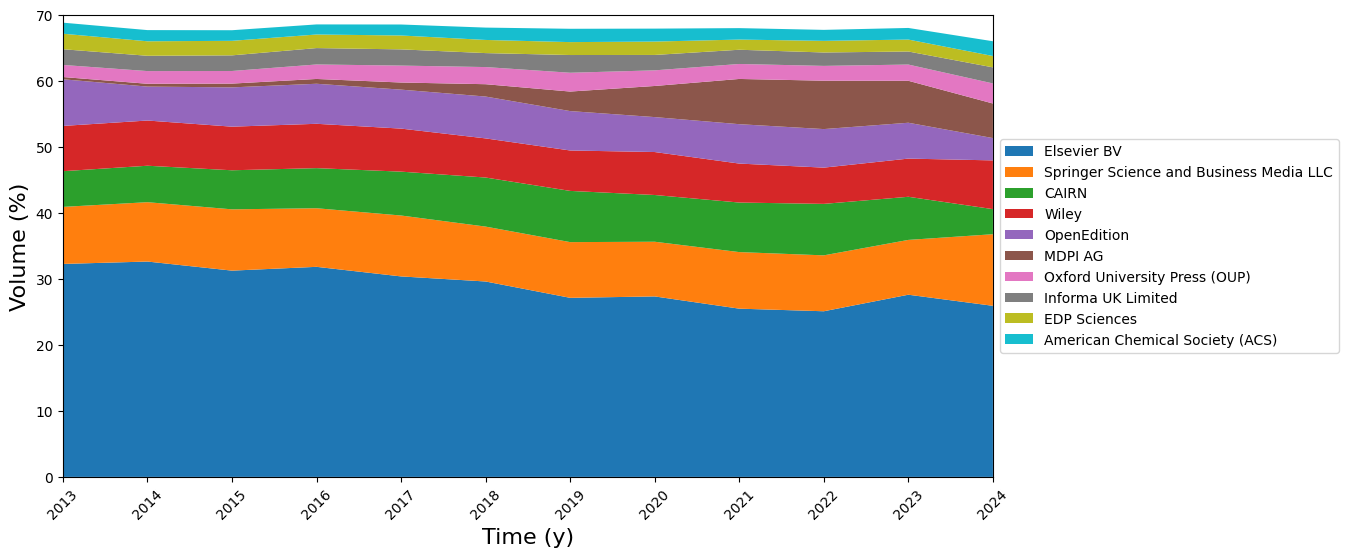

In [ ]:
df_inclusive['doi_prefix'] = df_inclusive.doi.apply(lambda x: x[16::].split('/')[0])

publisher = pd.read_csv('../data/external/publisher_doi_full.csv')

df_publisher = df_inclusive.merge(publisher, on = 'doi_prefix', how = 'left')

# THERE ARE 10924 DOIS (0.94% OF THEM) WITHOUT LINK

df_group = pd.read_csv('../data/external/publisher_group.csv', header = None)[1::]
df_group.columns = df_group.iloc[0]
df_group = df_group.iloc[1:].reset_index(drop=True)[['publisher_clean', 'publisher_group', 'group_start_date']]
pub_dict = df_group.set_index('publisher_clean')['publisher_group'].to_dict()
year_dict = df_group.set_index('publisher_clean')['group_start_date'].astype(int).to_dict()
mask = (df_publisher['publisher_y'].isin(pub_dict) & df_publisher['publisher_y'].isin(year_dict) & (df_publisher['publication_year'] >= df_publisher['publisher_y'].map(year_dict)))
df_publisher.loc[mask, 'publisher_y'] = df_publisher.loc[mask, 'publisher_y'].map(pub_dict)

top_publishers = list(df_publisher.groupby('publisher_y').count().sort_values('doi', ascending = False)[0:10].index)
years = range(2013, 2025)
df_per = pd.DataFrame(index = top_publishers, columns = years)
for year in years: 
    df_publisher_year = df_publisher[df_publisher.publication_year == year]  
    for publisher in top_publishers:
        df_publisher_year_publisher = df_publisher_year[df_publisher_year.publisher_y == publisher]            
        df_per.at[publisher, year] = df_publisher_year_publisher.doi.nunique() / df_publisher_year.doi.nunique()

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(df_per.columns.astype(int), df_per.values.astype(float) * 100, labels = df_per.index)
ax.set_xticks(np.arange(years[0], years[-1] + 1))
ax.set_xticklabels(np.arange(years[0], years[-1] + 1), rotation = 45)
ax.set_yticks(np.arange(0, 80, 10))
ax.set_yticklabels(np.arange(0, 80, 10))
ax.set_xlim(years[0], years[-1])
ax.set_ylim(0, 70)
ax.set_ylabel('Volume (%)', fontsize = 16)  
ax.set_xlabel('Time (y)', fontsize = 16)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))


## Integrate Open Apc

In [16]:
df_inclusive_paid = df_inclusive[df_inclusive.apc_paid.notna()].reset_index(drop = True)
df_money = pd.read_csv('EUR_USD_yearly_avg_2013_2024.csv').set_index('year')
df_inclusive_paid['apc_paid'] = df_inclusive_paid.apc_paid.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else {})
df_inclusive_paid['value_usd'] = df_inclusive_paid.apc_paid.apply(lambda x: x['value_usd'])
df_inclusive_paid['value_usd_to_eur'] = df_inclusive_paid.apply(lambda x: x['value_usd']*df_money.at[x['publication_year'], 'avg_eur_per_usd'], axis = 1)

df_inclusive_paid

,doi,publication_year,language,field_name_top_topic,journal,journal_id,issn_l,publisher,publisher_id,display_name_institution,...,doi_corr,BSO,keep_CA_position,priority,First_Last_FR,First_pct,Last_pct,Middle_pct,value_usd,value_usd_to_eur
0,https://doi.org/10.1016/j.rse.2012.12.008,2013,en,Environmental Science,Remote Sensing of Environment,S141808269,0034-4257,Elsevier BV,P4310320990,['Institute of Geographic Sciences and Natural...,...,10.1016/j.rse.2012.12.008,True,0.0,3.0,NaN,NaN,NaN,NaN,4070,3072.706520
1,https://doi.org/10.5194/bg-10-6225-2013,2013,en,Earth and Planetary Sciences,Biogeosciences,S13442111,1726-4170,Copernicus Publications,P4310313756,['Centre National de la Recherche Scientifique...,...,10.5194/bg-10-6225-2013,True,0.0,3.0,NaN,NaN,NaN,NaN,1628,1229.082608
2,https://doi.org/10.1016/j.mattod.2013.06.004,2013,en,Materials Science,Materials Today,S63322718,1369-7021,Elsevier BV,P4310320990,['Institut polytechnique de Grenoble'],...,10.1016/j.mattod.2013.06.004,True,0.0,3.0,NaN,NaN,NaN,NaN,5300,4001.313159
3,https://doi.org/10.1371/journal.pmed.1001453,2013,en,Medicine,PLoS Medicine,S197939330,1549-1277,Public Library of Science,P4310315706,"['La Ligue Contre le Cancer', 'La Ligue Contre...",...,10.1371/journal.pmed.1001453,True,0.0,3.0,NaN,NaN,NaN,NaN,5300,4001.313159
4,https://doi.org/10.1186/1754-6834-6-41,2013,en,Engineering,Biotechnology for Biofuels,S137860580,1754-6834,Springer Science+Business Media,P4310319900,"['Aix-Marseille Université', 'Aix-Marseille Un...",...,10.1186/1754-6834-6-41,True,0.0,3.0,NaN,NaN,NaN,NaN,2440,1842.113983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173854,https://doi.org/10.1007/s10618-023-00941-9,2023,en,Arts and Humanities,Data Mining and Knowledge Discovery,S121920818,NaN,Springer Science+Business Media,P4310319900,['FORTH Institute of Electronic Structure and ...,...,10.1007/s10618-023-00941-9,True,NaN,NaN,True,0.846154,0.076923,0.076923,2990,2774.593269
173855,https://doi.org/10.3390/su151410786,2023,en,"Business, Management and Accounting",Sustainability,S10134376,NaN,Multidisciplinary Digital Publishing Institute,P4310310987,"['NEOMA Business School', 'UCLouvain', 'L’Inst...",...,10.3390/su151410786,True,NaN,NaN,True,0.678771,0.153631,0.167598,2382,2210.395039
173856,https://doi.org/10.1140/epjs/s11734-023-00845-1,2023,lv,Physics and Astronomy,The European Physical Journal Special Topics,S138062970,NaN,Springer Science+Business Media,P4310319900,['Scuola Internazionale Superiore di Studi Ava...,...,10.1140/epjs/s11734-023-00845-1,True,NaN,NaN,True,0.777778,0.111111,0.111111,3590,3331.367838
173857,https://doi.org/10.1051/meca/2024015,2024,en,Engineering,Mechanics & Industry,S2479780166,NaN,EDP Sciences,P4310319748,"['""Dunarea de Jos"" University of Galati', '""Du...",...,10.1051/meca/2024015,True,NaN,NaN,True,0.833333,0.055556,0.111111,1186,1094.455690


In [17]:
interest_cols = ['doi', 'euro', 'issn_l', 'period']

df_open_apc = pd.read_csv('../data/external/apc_de.csv')[interest_cols]
df_inclusive_paid['doi'] = df_inclusive_paid.doi.apply(lambda x: x[16::])
df_inclusive_paid = df_inclusive_paid.merge(df_open_apc[['doi', 'euro']], on = 'doi', how = 'left')
print(len(df_inclusive_paid[df_inclusive_paid.euro.notna()]))
df_inclusive_paid

/tmp/ipykernel_4103/864502945.py:3: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df_open_apc = pd.read_csv('../data/external/apc_de.csv')[interest_cols]


30440


,doi,publication_year,language,field_name_top_topic,journal,journal_id,issn_l,publisher,publisher_id,display_name_institution,...,BSO,keep_CA_position,priority,First_Last_FR,First_pct,Last_pct,Middle_pct,value_usd,value_usd_to_eur,euro
0,10.1016/j.rse.2012.12.008,2013,en,Environmental Science,Remote Sensing of Environment,S141808269,0034-4257,Elsevier BV,P4310320990,['Institute of Geographic Sciences and Natural...,...,True,0.0,3.0,NaN,NaN,NaN,NaN,4070,3072.706520,NaN
1,10.5194/bg-10-6225-2013,2013,en,Earth and Planetary Sciences,Biogeosciences,S13442111,1726-4170,Copernicus Publications,P4310313756,['Centre National de la Recherche Scientifique...,...,True,0.0,3.0,NaN,NaN,NaN,NaN,1628,1229.082608,NaN
2,10.1016/j.mattod.2013.06.004,2013,en,Materials Science,Materials Today,S63322718,1369-7021,Elsevier BV,P4310320990,['Institut polytechnique de Grenoble'],...,True,0.0,3.0,NaN,NaN,NaN,NaN,5300,4001.313159,NaN
3,10.1371/journal.pmed.1001453,2013,en,Medicine,PLoS Medicine,S197939330,1549-1277,Public Library of Science,P4310315706,"['La Ligue Contre le Cancer', 'La Ligue Contre...",...,True,0.0,3.0,NaN,NaN,NaN,NaN,5300,4001.313159,NaN
4,10.1186/1754-6834-6-41,2013,en,Engineering,Biotechnology for Biofuels,S137860580,1754-6834,Springer Science+Business Media,P4310319900,"['Aix-Marseille Université', 'Aix-Marseille Un...",...,True,0.0,3.0,NaN,NaN,NaN,NaN,2440,1842.113983,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173854,10.1007/s10618-023-00941-9,2023,en,Arts and Humanities,Data Mining and Knowledge Discovery,S121920818,NaN,Springer Science+Business Media,P4310319900,['FORTH Institute of Electronic Structure and ...,...,True,NaN,NaN,True,0.846154,0.076923,0.076923,2990,2774.593269,NaN
173855,10.3390/su151410786,2023,en,"Business, Management and Accounting",Sustainability,S10134376,NaN,Multidisciplinary Digital Publishing Institute,P4310310987,"['NEOMA Business School', 'UCLouvain', 'L’Inst...",...,True,NaN,NaN,True,0.678771,0.153631,0.167598,2382,2210.395039,NaN
173856,10.1140/epjs/s11734-023-00845-1,2023,lv,Physics and Astronomy,The European Physical Journal Special Topics,S138062970,NaN,Springer Science+Business Media,P4310319900,['Scuola Internazionale Superiore di Studi Ava...,...,True,NaN,NaN,True,0.777778,0.111111,0.111111,3590,3331.367838,NaN
173857,10.1051/meca/2024015,2024,en,Engineering,Mechanics & Industry,S2479780166,NaN,EDP Sciences,P4310319748,"['""Dunarea de Jos"" University of Galati', '""Du...",...,True,NaN,NaN,True,0.833333,0.055556,0.111111,1186,1094.455690,NaN


### Open Alex cost

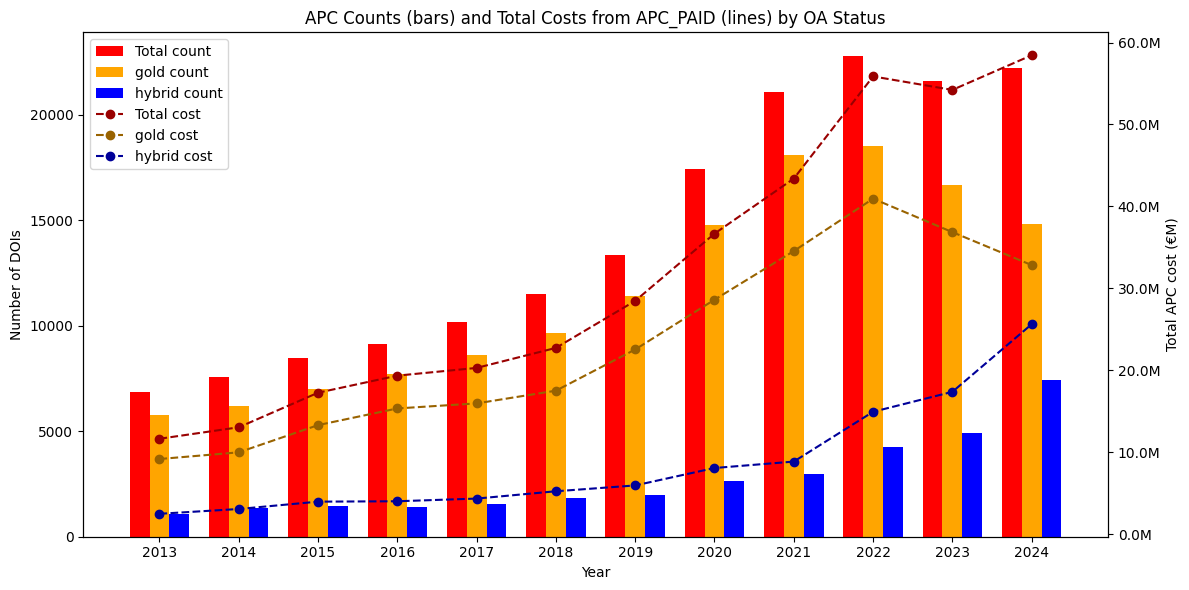

In [11]:
df_inclusive_paid_tmp_0 = df_inclusive_paid.copy()
df_inclusive_paid_tmp_0['fr_cost'] = df_inclusive_paid_tmp_0.value_usd_to_eur

df_inclusive_paid_tmp_0_oa_gold_hyb = df_inclusive_paid_tmp_0[df_inclusive_paid_tmp_0.oa_status.isin(['hybrid', 'gold'])].reset_index(drop = True)
status = df_inclusive_paid_tmp_0_oa_gold_hyb.groupby(['publication_year', 'oa_status']).agg({'doi':'count', 'fr_cost': 'sum'})
total = df_inclusive_paid_tmp_0_oa_gold_hyb.groupby(['publication_year']).agg({'doi':'count', 'fr_cost': 'sum'})
total['oa_status'] = 'Total'
total = total.set_index('oa_status', append=True)
df_data = pd.concat([status, total]).sort_index()

bar_width = 0.25
years = sorted(df_inclusive_paid_tmp_0_oa_gold_hyb.publication_year.unique())
x = np.arange(len(years))

fig, ax1 = plt.subplots(figsize=(12,6))

colors = {'gold':'orange', 'hybrid':'blue', 'Total':'red'}

# Function to darken a color
def darken_color(color, amount=0.6):
    c = mcolors.to_rgb(color)
    return (c[0]*amount, c[1]*amount, c[2]*amount)

# Plot bars for counts
count_df = df_data['doi'].unstack('oa_status').fillna(0)
for i, col in enumerate(count_df.columns):
    ax1.bar(x + i*bar_width, count_df[col], width=bar_width, color=colors.get(col,'grey'), label=f"{col} count")

ax1.set_ylabel('Number of DOIs')
ax1.set_xlabel('Year')
ax1.set_xticks(x + bar_width)  # center x-ticks under grouped bars
ax1.set_xticklabels(years)

# Right axis for cost lines
cost_df = df_data['fr_cost'].unstack('oa_status').fillna(0)
ax2 = ax1.twinx()
for col in cost_df.columns:
    dark_color = darken_color(colors.get(col,'grey'))
    ax2.plot(x + bar_width, cost_df[col], color=dark_color, marker='o', linestyle='--', label=f"{col} cost")

# Format y-axis in millions
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*1e-6:.1f}M'))

ax2.set_ylabel('Total APC cost (€M)')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('APC Counts (bars) and Total Costs from APC_PAID (lines) by OA Status')
plt.tight_layout()
plt.show()

### Detect Outliers and infer trends 

In [18]:
df_open_apc['log_price'] = np.log1p(df_open_apc['euro'])
journal_stats = (df_open_apc.groupby('issn_l')['log_price'].agg(median = 'median', mad = lambda x: np.median(np.abs(x - np.median(x))), count = 'size').reset_index())

df_open_apc = df_open_apc.merge(journal_stats, on = 'issn_l', how = 'left')
df_open_apc['journal_mad_score'] = np.abs(df_open_apc['log_price'] - df_open_apc['median']) / df_open_apc['mad']

df_open_apc['is_outlier'] = ((df_open_apc['count'] >= 10) & (df_open_apc['journal_mad_score'] > 4))

df_open_apc = df_open_apc[df_open_apc.is_outlier == False].reset_index(drop = True)
df_open_apc

,doi,euro,issn_l,period,log_price,median,mad,count,journal_mad_score,is_outlier
0,10.3389/fpsyg.2013.00318,960.00,1664-1078,2013,6.867974,7.601002,0.200280,3332.0,3.660008,False
1,10.3389/fpsyg.2013.00406,960.00,1664-1078,2013,6.867974,7.601002,0.200280,3332.0,3.660008,False
2,10.3389/fpsyg.2013.00453,960.00,1664-1078,2013,6.867974,7.601002,0.200280,3332.0,3.660008,False
3,10.6000/1929-4409.2013.02.32,182.00,1929-4409,2013,5.209486,5.744060,0.534574,3.0,1.000000,False
4,10.1068/i0605,405.79,2041-6695,2013,6.008297,6.267513,0.314498,78.0,0.824223,False
...,...,...,...,...,...,...,...,...,...,...
241832,10.3390/mti9070072,1928.90,2414-4088,2025,7.565223,7.258743,0.263051,33.0,1.165098,False
241833,10.1098/rsos.250490,1581.30,2054-5703,2025,7.366635,7.159447,0.172074,228.0,1.204059,False
241834,10.3389/frcha.2025.1637011,2117.31,2813-4540,2025,7.658374,7.707267,0.042535,4.0,1.149487,False
241835,10.1093/femsec/fiaf081,2298.71,0168-6496,2025,7.740538,7.934986,0.103853,41.0,1.872332,False


### Median

In [24]:
threshold = 3
grouped = df_open_apc.groupby(['issn_l', 'period'])['euro'].agg(median = 'median', count = 'size')
grouped = grouped[grouped['count'] > threshold].reset_index().drop(columns = 'count')
print(len(df_open_apc[df_open_apc.issn_l.isin(grouped.issn_l)]), grouped.issn_l.nunique())

df_inclusive_paid_tmp_1 = df_inclusive_paid.merge(grouped, left_on = ['issn_l', 'publication_year'], right_on = ['issn_l', 'period'], how = 'left')
print(len(df_inclusive_paid_tmp_1[(df_inclusive_paid_tmp_1['median'].notna()) & (df_inclusive_paid.euro.isna())]))
df_inclusive_paid_tmp_1

216204 2832
89572


,doi,publication_year,language,field_name_top_topic,journal,journal_id,issn_l,publisher,publisher_id,display_name_institution,...,priority,First_Last_FR,First_pct,Last_pct,Middle_pct,value_usd,value_usd_to_eur,euro,period,median
0,10.1016/j.rse.2012.12.008,2013,en,Environmental Science,Remote Sensing of Environment,S141808269,0034-4257,Elsevier BV,P4310320990,['Institute of Geographic Sciences and Natural...,...,3.0,NaN,NaN,NaN,NaN,4070,3072.706520,NaN,NaN,NaN
1,10.5194/bg-10-6225-2013,2013,en,Earth and Planetary Sciences,Biogeosciences,S13442111,1726-4170,Copernicus Publications,P4310313756,['Centre National de la Recherche Scientifique...,...,3.0,NaN,NaN,NaN,NaN,1628,1229.082608,NaN,2013.0,1236.1
2,10.1016/j.mattod.2013.06.004,2013,en,Materials Science,Materials Today,S63322718,1369-7021,Elsevier BV,P4310320990,['Institut polytechnique de Grenoble'],...,3.0,NaN,NaN,NaN,NaN,5300,4001.313159,NaN,NaN,NaN
3,10.1371/journal.pmed.1001453,2013,en,Medicine,PLoS Medicine,S197939330,1549-1277,Public Library of Science,P4310315706,"['La Ligue Contre le Cancer', 'La Ligue Contre...",...,3.0,NaN,NaN,NaN,NaN,5300,4001.313159,NaN,NaN,NaN
4,10.1186/1754-6834-6-41,2013,en,Engineering,Biotechnology for Biofuels,S137860580,1754-6834,Springer Science+Business Media,P4310319900,"['Aix-Marseille Université', 'Aix-Marseille Un...",...,3.0,NaN,NaN,NaN,NaN,2440,1842.113983,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173854,10.1007/s10618-023-00941-9,2023,en,Arts and Humanities,Data Mining and Knowledge Discovery,S121920818,NaN,Springer Science+Business Media,P4310319900,['FORTH Institute of Electronic Structure and ...,...,NaN,True,0.846154,0.076923,0.076923,2990,2774.593269,NaN,NaN,NaN
173855,10.3390/su151410786,2023,en,"Business, Management and Accounting",Sustainability,S10134376,NaN,Multidisciplinary Digital Publishing Institute,P4310310987,"['NEOMA Business School', 'UCLouvain', 'L’Inst...",...,NaN,True,0.678771,0.153631,0.167598,2382,2210.395039,NaN,NaN,NaN
173856,10.1140/epjs/s11734-023-00845-1,2023,lv,Physics and Astronomy,The European Physical Journal Special Topics,S138062970,NaN,Springer Science+Business Media,P4310319900,['Scuola Internazionale Superiore di Studi Ava...,...,NaN,True,0.777778,0.111111,0.111111,3590,3331.367838,NaN,NaN,NaN
173857,10.1051/meca/2024015,2024,en,Engineering,Mechanics & Industry,S2479780166,NaN,EDP Sciences,P4310319748,"['""Dunarea de Jos"" University of Galati', '""Du...",...,NaN,True,0.833333,0.055556,0.111111,1186,1094.455690,NaN,NaN,NaN


In [25]:
def price(row):
    if 0 in row['french_position']:
        return row['First_pct'] * row['price_var']
    if row['len'] - 1 in row['french_position']:
        return row['Last_pct'] * row['price_var']
    else:
        return len(row['french_position']) * row['price_var'] * row['len'] / (row['len'] - 2)
    


df_inclusive_paid_tmp_1['price_var'] = df_inclusive_paid_tmp_1.apply(lambda x: x['euro'] if pd.notna(x['euro']) else x['median'] if pd.notna(x['median']) else x['value_usd_to_eur'], axis = 1)
df_inclusive_paid_tmp_1['french_position'] = df_inclusive_paid_tmp_1['countries'].apply(lambda lst: [i for i, inner in enumerate(lst) if 'FR' in inner])
df_inclusive_paid_tmp_1['len'] = df_inclusive_paid_tmp_1['corresponding'].apply(lambda x: len(x))
df_inclusive_paid_tmp_1['fr_cost'] = df_inclusive_paid_tmp_1.apply(lambda x: x['price_var'] if pd.isna(x['First_Last_FR']) else price(x), axis = 1)

df_inclusive_paid_tmp_1

,doi,publication_year,language,field_name_top_topic,journal,journal_id,issn_l,publisher,publisher_id,display_name_institution,...,Middle_pct,value_usd,value_usd_to_eur,euro,period,median,price_var,french_position,len,fr_cost
0,10.1016/j.rse.2012.12.008,2013,en,Environmental Science,Remote Sensing of Environment,S141808269,0034-4257,Elsevier BV,P4310320990,['Institute of Geographic Sciences and Natural...,...,NaN,4070,3072.706520,NaN,NaN,NaN,3072.706520,[0],8,3072.706520
1,10.5194/bg-10-6225-2013,2013,en,Earth and Planetary Sciences,Biogeosciences,S13442111,1726-4170,Copernicus Publications,P4310313756,['Centre National de la Recherche Scientifique...,...,NaN,1628,1229.082608,NaN,2013.0,1236.1,1236.100000,"[0, 1, 2, 5, 9]",12,1236.100000
2,10.1016/j.mattod.2013.06.004,2013,en,Materials Science,Materials Today,S63322718,1369-7021,Elsevier BV,P4310320990,['Institut polytechnique de Grenoble'],...,NaN,5300,4001.313159,NaN,NaN,NaN,4001.313159,[0],1,4001.313159
3,10.1371/journal.pmed.1001453,2013,en,Medicine,PLoS Medicine,S197939330,1549-1277,Public Library of Science,P4310315706,"['La Ligue Contre le Cancer', 'La Ligue Contre...",...,NaN,5300,4001.313159,NaN,NaN,NaN,4001.313159,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14,...",24,4001.313159
4,10.1186/1754-6834-6-41,2013,en,Engineering,Biotechnology for Biofuels,S137860580,1754-6834,Springer Science+Business Media,P4310319900,"['Aix-Marseille Université', 'Aix-Marseille Un...",...,NaN,2440,1842.113983,NaN,NaN,NaN,1842.113983,"[0, 1, 2, 3, 4]",5,1842.113983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173854,10.1007/s10618-023-00941-9,2023,en,Arts and Humanities,Data Mining and Knowledge Discovery,S121920818,NaN,Springer Science+Business Media,P4310319900,['FORTH Institute of Electronic Structure and ...,...,0.076923,2990,2774.593269,NaN,NaN,NaN,2774.593269,"[2, 3]",4,213.430251
173855,10.3390/su151410786,2023,en,"Business, Management and Accounting",Sustainability,S10134376,NaN,Multidisciplinary Digital Publishing Institute,P4310310987,"['NEOMA Business School', 'UCLouvain', 'L’Inst...",...,0.167598,2382,2210.395039,NaN,NaN,NaN,2210.395039,[0],4,1500.351940
173856,10.1140/epjs/s11734-023-00845-1,2023,lv,Physics and Astronomy,The European Physical Journal Special Topics,S138062970,NaN,Springer Science+Business Media,P4310319900,['Scuola Internazionale Superiore di Studi Ava...,...,0.111111,3590,3331.367838,NaN,NaN,NaN,3331.367838,[1],2,370.151982
173857,10.1051/meca/2024015,2024,en,Engineering,Mechanics & Industry,S2479780166,NaN,EDP Sciences,P4310319748,"['""Dunarea de Jos"" University of Galati', '""Du...",...,0.111111,1186,1094.455690,NaN,NaN,NaN,1094.455690,[5],6,60.803094


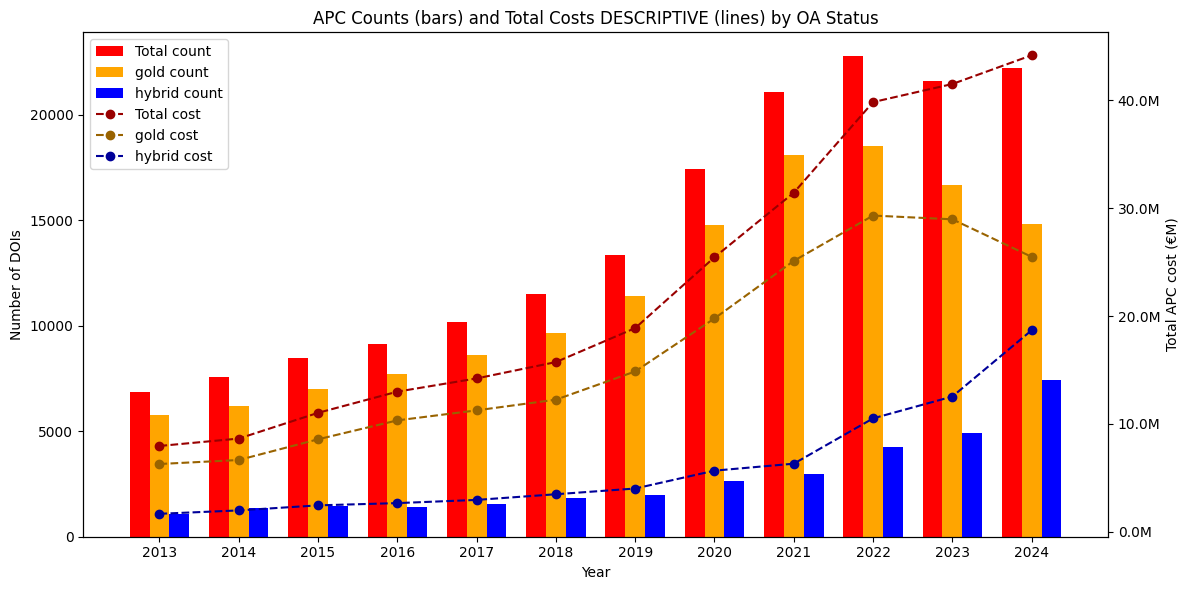

In [27]:
df_inclusive_paid_tmp_1_oa_gold_hyb = df_inclusive_paid_tmp_1[df_inclusive_paid_tmp_1.oa_status.isin(['hybrid', 'gold'])].reset_index(drop = True)
status = df_inclusive_paid_tmp_1_oa_gold_hyb.groupby(['publication_year', 'oa_status']).agg({'doi':'count', 'fr_cost': 'sum'})
total = df_inclusive_paid_tmp_1_oa_gold_hyb.groupby(['publication_year']).agg({'doi':'count', 'fr_cost': 'sum'})
total['oa_status'] = 'Total'
total = total.set_index('oa_status', append=True)
df_data = pd.concat([status, total]).sort_index()

bar_width = 0.25
years = sorted(df_inclusive_paid_tmp_1_oa_gold_hyb.publication_year.unique())
x = np.arange(len(years))

fig, ax1 = plt.subplots(figsize=(12,6))

colors = {'gold':'orange', 'hybrid':'blue', 'Total':'red'}

# Function to darken a color
def darken_color(color, amount=0.6):
    c = mcolors.to_rgb(color)
    return (c[0]*amount, c[1]*amount, c[2]*amount)

# Plot bars for counts
count_df = df_data['doi'].unstack('oa_status').fillna(0)
for i, col in enumerate(count_df.columns):
    ax1.bar(x + i*bar_width, count_df[col], width=bar_width, color=colors.get(col,'grey'), label=f"{col} count")

ax1.set_ylabel('Number of DOIs')
ax1.set_xlabel('Year')
ax1.set_xticks(x + bar_width)  # center x-ticks under grouped bars
ax1.set_xticklabels(years)

# Right axis for cost lines
cost_df = df_data['fr_cost'].unstack('oa_status').fillna(0)
ax2 = ax1.twinx()
for col in cost_df.columns:
    dark_color = darken_color(colors.get(col,'grey'))
    ax2.plot(x + bar_width, cost_df[col], color=dark_color, marker='o', linestyle='--', label=f"{col} cost")

# Format y-axis in millions
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*1e-6:.1f}M'))

ax2.set_ylabel('Total APC cost (€M)')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('APC Counts (bars) and Total Costs DESCRIPTIVE (lines) by OA Status')
plt.tight_layout()
plt.show()

### Linear regression

In [32]:
threshold = 30

df_open_apc['is_outlier'] = ((df_open_apc['count'] >= 10) & (df_open_apc['journal_mad_score'] > 4))

df_model = df_open_apc.copy()
df_model['year_centered'] = df_model['period'] - df_model['period'].min()
results = []
for journal, g in df_model.groupby('issn_l'):
    if len(g) >= threshold: 
        X = g[['year_centered']].values   # predictor
        y = g['euro'].values    # response
        model = LinearRegression()
        model.fit(X, y)
        results.append({
            'journal': journal,
            'slope': model.coef_[0],         # yearly change in price
            'intercept': model.intercept_,   # baseline price
            'n_papers': len(g)
        })
df_reg = pd.DataFrame(results)
df_reg_tmp_1 = df_reg[df_reg.slope > 0].reset_index(drop = True) # PRICE SHOULD INCREASE
df_reg_tmp_2 = df_reg_tmp_1[df_reg_tmp_1.intercept > 0].reset_index(drop = True).set_index('journal')
print(len(df_open_apc[df_open_apc.issn_l.isin(df_reg_tmp_2.index)]), df_reg_tmp_2.index.nunique())
print(len(df_inclusive_paid[(df_inclusive_paid['issn_l'].isin(df_reg_tmp_2.index)) & (df_inclusive_paid.euro.isna())]))
df_inclusive_paid_tmp_2 = df_inclusive_paid.copy()
df_inclusive_paid_tmp_2['reg'] = df_inclusive_paid_tmp_2.apply(lambda x: ((x['publication_year'] - df_model['period'].min()) * df_reg_tmp_2.at[x['issn_l'], 'slope'] + df_reg_tmp_2.at[x['issn_l'], 'intercept'])
                                                                          if (x['issn_l'] in df_reg_tmp_2.index and pd.isna(x['euro'])) else None, axis = 1)
df_inclusive_paid_tmp_2

123531 717
61490


,doi,publication_year,language,field_name_top_topic,journal,journal_id,issn_l,publisher,publisher_id,display_name_institution,...,keep_CA_position,priority,First_Last_FR,First_pct,Last_pct,Middle_pct,value_usd,value_usd_to_eur,euro,reg
0,10.1016/j.rse.2012.12.008,2013,en,Environmental Science,Remote Sensing of Environment,S141808269,0034-4257,Elsevier BV,P4310320990,['Institute of Geographic Sciences and Natural...,...,0.0,3.0,NaN,NaN,NaN,NaN,4070,3072.706520,NaN,NaN
1,10.5194/bg-10-6225-2013,2013,en,Earth and Planetary Sciences,Biogeosciences,S13442111,1726-4170,Copernicus Publications,P4310313756,['Centre National de la Recherche Scientifique...,...,0.0,3.0,NaN,NaN,NaN,NaN,1628,1229.082608,NaN,1501.172378
2,10.1016/j.mattod.2013.06.004,2013,en,Materials Science,Materials Today,S63322718,1369-7021,Elsevier BV,P4310320990,['Institut polytechnique de Grenoble'],...,0.0,3.0,NaN,NaN,NaN,NaN,5300,4001.313159,NaN,NaN
3,10.1371/journal.pmed.1001453,2013,en,Medicine,PLoS Medicine,S197939330,1549-1277,Public Library of Science,P4310315706,"['La Ligue Contre le Cancer', 'La Ligue Contre...",...,0.0,3.0,NaN,NaN,NaN,NaN,5300,4001.313159,NaN,2423.636072
4,10.1186/1754-6834-6-41,2013,en,Engineering,Biotechnology for Biofuels,S137860580,1754-6834,Springer Science+Business Media,P4310319900,"['Aix-Marseille Université', 'Aix-Marseille Un...",...,0.0,3.0,NaN,NaN,NaN,NaN,2440,1842.113983,NaN,1726.973814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173854,10.1007/s10618-023-00941-9,2023,en,Arts and Humanities,Data Mining and Knowledge Discovery,S121920818,NaN,Springer Science+Business Media,P4310319900,['FORTH Institute of Electronic Structure and ...,...,NaN,NaN,True,0.846154,0.076923,0.076923,2990,2774.593269,NaN,NaN
173855,10.3390/su151410786,2023,en,"Business, Management and Accounting",Sustainability,S10134376,NaN,Multidisciplinary Digital Publishing Institute,P4310310987,"['NEOMA Business School', 'UCLouvain', 'L’Inst...",...,NaN,NaN,True,0.678771,0.153631,0.167598,2382,2210.395039,NaN,NaN
173856,10.1140/epjs/s11734-023-00845-1,2023,lv,Physics and Astronomy,The European Physical Journal Special Topics,S138062970,NaN,Springer Science+Business Media,P4310319900,['Scuola Internazionale Superiore di Studi Ava...,...,NaN,NaN,True,0.777778,0.111111,0.111111,3590,3331.367838,NaN,NaN
173857,10.1051/meca/2024015,2024,en,Engineering,Mechanics & Industry,S2479780166,NaN,EDP Sciences,P4310319748,"['""Dunarea de Jos"" University of Galati', '""Du...",...,NaN,NaN,True,0.833333,0.055556,0.111111,1186,1094.455690,NaN,NaN


In [33]:
def price(row):
    if 0 in row['french_position']:
        return row['First_pct'] * row['price_var']
    if row['len'] - 1 in row['french_position']:
        return row['Last_pct'] * row['price_var']
    else:
        return len(row['french_position']) * row['price_var'] * row['len'] / (row['len'] - 2)
    


df_inclusive_paid_tmp_2['price_var'] = df_inclusive_paid_tmp_2.apply(lambda x: x['euro'] if pd.notna(x['euro']) else x['reg'] if pd.notna(x['reg']) else x['value_usd_to_eur'], axis = 1)
df_inclusive_paid_tmp_2['french_position'] = df_inclusive_paid_tmp_2['countries'].apply(lambda lst: [i for i, inner in enumerate(lst) if 'FR' in inner])
df_inclusive_paid_tmp_2['len'] = df_inclusive_paid_tmp_2['corresponding'].apply(lambda x: len(x))
df_inclusive_paid_tmp_2['fr_cost'] = df_inclusive_paid_tmp_2.apply(lambda x: x['price_var'] if pd.isna(x['First_Last_FR']) else price(x), axis = 1)

df_inclusive_paid_tmp_2

,doi,publication_year,language,field_name_top_topic,journal,journal_id,issn_l,publisher,publisher_id,display_name_institution,...,Last_pct,Middle_pct,value_usd,value_usd_to_eur,euro,reg,price_var,french_position,len,fr_cost
0,10.1016/j.rse.2012.12.008,2013,en,Environmental Science,Remote Sensing of Environment,S141808269,0034-4257,Elsevier BV,P4310320990,['Institute of Geographic Sciences and Natural...,...,NaN,NaN,4070,3072.706520,NaN,NaN,3072.706520,[0],8,3072.706520
1,10.5194/bg-10-6225-2013,2013,en,Earth and Planetary Sciences,Biogeosciences,S13442111,1726-4170,Copernicus Publications,P4310313756,['Centre National de la Recherche Scientifique...,...,NaN,NaN,1628,1229.082608,NaN,1501.172378,1501.172378,"[0, 1, 2, 5, 9]",12,1501.172378
2,10.1016/j.mattod.2013.06.004,2013,en,Materials Science,Materials Today,S63322718,1369-7021,Elsevier BV,P4310320990,['Institut polytechnique de Grenoble'],...,NaN,NaN,5300,4001.313159,NaN,NaN,4001.313159,[0],1,4001.313159
3,10.1371/journal.pmed.1001453,2013,en,Medicine,PLoS Medicine,S197939330,1549-1277,Public Library of Science,P4310315706,"['La Ligue Contre le Cancer', 'La Ligue Contre...",...,NaN,NaN,5300,4001.313159,NaN,2423.636072,2423.636072,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14,...",24,2423.636072
4,10.1186/1754-6834-6-41,2013,en,Engineering,Biotechnology for Biofuels,S137860580,1754-6834,Springer Science+Business Media,P4310319900,"['Aix-Marseille Université', 'Aix-Marseille Un...",...,NaN,NaN,2440,1842.113983,NaN,1726.973814,1726.973814,"[0, 1, 2, 3, 4]",5,1726.973814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173854,10.1007/s10618-023-00941-9,2023,en,Arts and Humanities,Data Mining and Knowledge Discovery,S121920818,NaN,Springer Science+Business Media,P4310319900,['FORTH Institute of Electronic Structure and ...,...,0.076923,0.076923,2990,2774.593269,NaN,NaN,2774.593269,"[2, 3]",4,213.430251
173855,10.3390/su151410786,2023,en,"Business, Management and Accounting",Sustainability,S10134376,NaN,Multidisciplinary Digital Publishing Institute,P4310310987,"['NEOMA Business School', 'UCLouvain', 'L’Inst...",...,0.153631,0.167598,2382,2210.395039,NaN,NaN,2210.395039,[0],4,1500.351940
173856,10.1140/epjs/s11734-023-00845-1,2023,lv,Physics and Astronomy,The European Physical Journal Special Topics,S138062970,NaN,Springer Science+Business Media,P4310319900,['Scuola Internazionale Superiore di Studi Ava...,...,0.111111,0.111111,3590,3331.367838,NaN,NaN,3331.367838,[1],2,370.151982
173857,10.1051/meca/2024015,2024,en,Engineering,Mechanics & Industry,S2479780166,NaN,EDP Sciences,P4310319748,"['""Dunarea de Jos"" University of Galati', '""Du...",...,0.055556,0.111111,1186,1094.455690,NaN,NaN,1094.455690,[5],6,60.803094


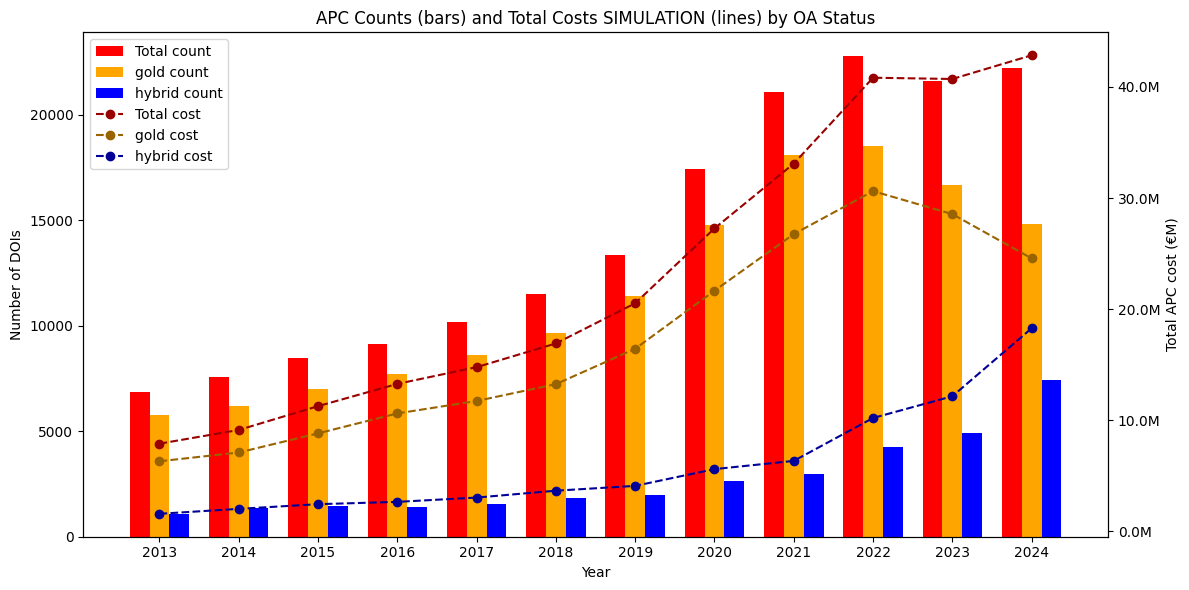

In [34]:
df_inclusive_paid_tmp_2_oa_gold_hyb = df_inclusive_paid_tmp_2[df_inclusive_paid_tmp_2.oa_status.isin(['hybrid', 'gold'])].reset_index(drop = True)
status = df_inclusive_paid_tmp_2_oa_gold_hyb.groupby(['publication_year', 'oa_status']).agg({'doi':'count', 'fr_cost': 'sum'})
total = df_inclusive_paid_tmp_2_oa_gold_hyb.groupby(['publication_year']).agg({'doi':'count', 'fr_cost': 'sum'})
total['oa_status'] = 'Total'
total = total.set_index('oa_status', append=True)
df_data = pd.concat([status, total]).sort_index()

bar_width = 0.25
years = sorted(df_inclusive_paid_tmp_2_oa_gold_hyb.publication_year.unique())
x = np.arange(len(years))

fig, ax1 = plt.subplots(figsize=(12,6))

colors = {'gold':'orange', 'hybrid':'blue', 'Total':'red'}

# Function to darken a color
def darken_color(color, amount=0.6):
    c = mcolors.to_rgb(color)
    return (c[0]*amount, c[1]*amount, c[2]*amount)
cost_df
# Plot bars for counts
count_df = df_data['doi'].unstack('oa_status').fillna(0)
for i, col in enumerate(count_df.columns):
    ax1.bar(x + i*bar_width, count_df[col], width=bar_width, color=colors.get(col,'grey'), label=f"{col} count")

ax1.set_ylabel('Number of DOIs')
ax1.set_xlabel('Year')
ax1.set_xticks(x + bar_width)  # center x-ticks under grouped bars
ax1.set_xticklabels(years)

# Right axis for cost lines
cost_df = df_data['fr_cost'].unstack('oa_status').fillna(0)
ax2 = ax1.twinx()
for col in cost_df.columns:
    dark_color = darken_color(colors.get(col,'grey'))
    ax2.plot(x + bar_width, cost_df[col], color=dark_color, marker='o', linestyle='--', label=f"{col} cost")

# Format y-axis in millions
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*1e-6:.1f}M'))

ax2.set_ylabel('Total APC cost (€M)')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('APC Counts (bars) and Total Costs SIMULATION (lines) by OA Status')
plt.tight_layout()
plt.show()